In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import os

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from wsd.models import JMDict, PointWiseRanker, GeminiRanker
from wsd.utils import load_dataset, accuracy

In [37]:
basedir = os.getenv('PJ_DIR')
X, y = load_dataset(f'{basedir}/data/dataset_.xml')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=44)

In [17]:
jmdict_base = JMDict()
base_preds = jmdict_base.predict(X_test)

100%|██████████| 8/8 [00:00<00:00, 17895.70it/s]


In [ ]:
model = LogisticRegression(C=10, penalty='l1', solver='liblinear')
ranker = PointWiseRanker(ranking_model=model)
jmdict_basic = JMDict(ranker=ranker)
jmdict_basic.fit(X_train, y_train)
basic_preds = jmdict_basic.predict(X_test)

100%|██████████| 8/8 [00:00<00:00, 309.44it/s]


In [19]:
ranker = GeminiRanker("gemini-2.5-flash-lite")
jmdict_gemini = JMDict(ranker=ranker)
gemini_preds = jmdict_gemini.predict(X_test)

100%|██████████| 8/8 [02:58<00:00, 22.30s/it]


In [20]:
print(f"baseline = {accuracy(base_preds, y_test):.2%}")
print(f"basic\t = {accuracy(basic_preds, y_test):.2%}")
print(f"gemini\t = {accuracy(gemini_preds, y_test):.2%}")

baseline = 49.62%
basic	 = 60.31%
gemini	 = 80.15%


<Axes: title={'center': 'Basic Ranker Coefficients'}>

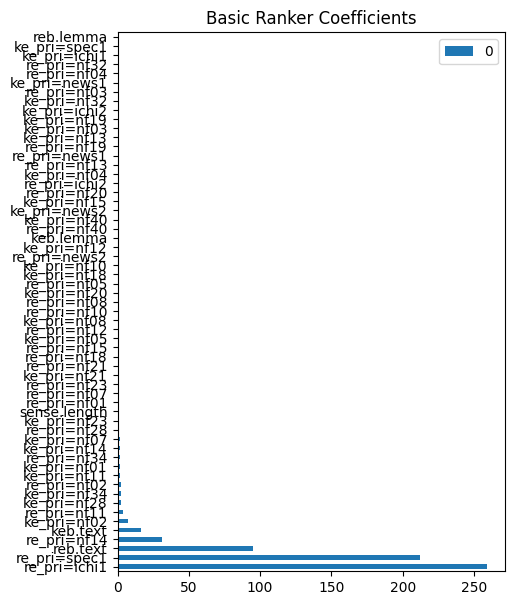

In [38]:
import pandas as pd
import numpy as np

jmdict_basic.fit(X_train, y_train)
pd.DataFrame(
    np.exp(jmdict_basic.ranker.model.coef_), 
    columns=jmdict_basic.ranker.vec.get_feature_names_out()
).T\
    .sort_values(by=0, ascending=False)\
    .plot(kind='barh', figsize=(5, 7), title='Basic Ranker Coefficients')

In [35]:
jmdict_basic.ranker.model.coef_

array([[ 0.00000000e+00, -2.90281631e-02, -4.90913157e-01,
        -1.05428237e-01,  0.00000000e+00,  4.19182183e-01,
         0.00000000e+00,  2.78118162e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  9.07715233e-01,
         0.00000000e+00, -1.38683637e+00,  0.00000000e+00,
         0.00000000e+00, -1.75750801e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -3.07991482e+00,
         0.00000000e+00,  1.35786622e-01,  1.13208954e+00,
        -1.01917693e-04, -2.07167330e-01, -8.86978453e-01,
         0.00000000e+00,  1.14477566e+00,  0.00000000e+00,
         2.50980163e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.43010440e+00,  0.00000000e+00,
        -4.00766634e-02,  0.00000000e+00,  0.00000000e+00,
        -6.04083083e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  5.86520815e+00, -6.61320415e+00,
         3.93590717e+00,  2.00444485e-01]])

In [31]:
jmdict_basic.ranker.model.classes_

array([False,  True])